In [1]:
# Model Based approaches: Linear, Exponential, Additive, Multiplicative, Quadratic
# Data driven approaches: AR, MA, ARMA, ARIMA (p-order of auto regressive model, d-order of differencing, q-order of moving avg model)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')
plt.rcParams['figure.dpi'] = 250
plt.rcParams['figure.figsize'] = (40,10)
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

<Axes: >

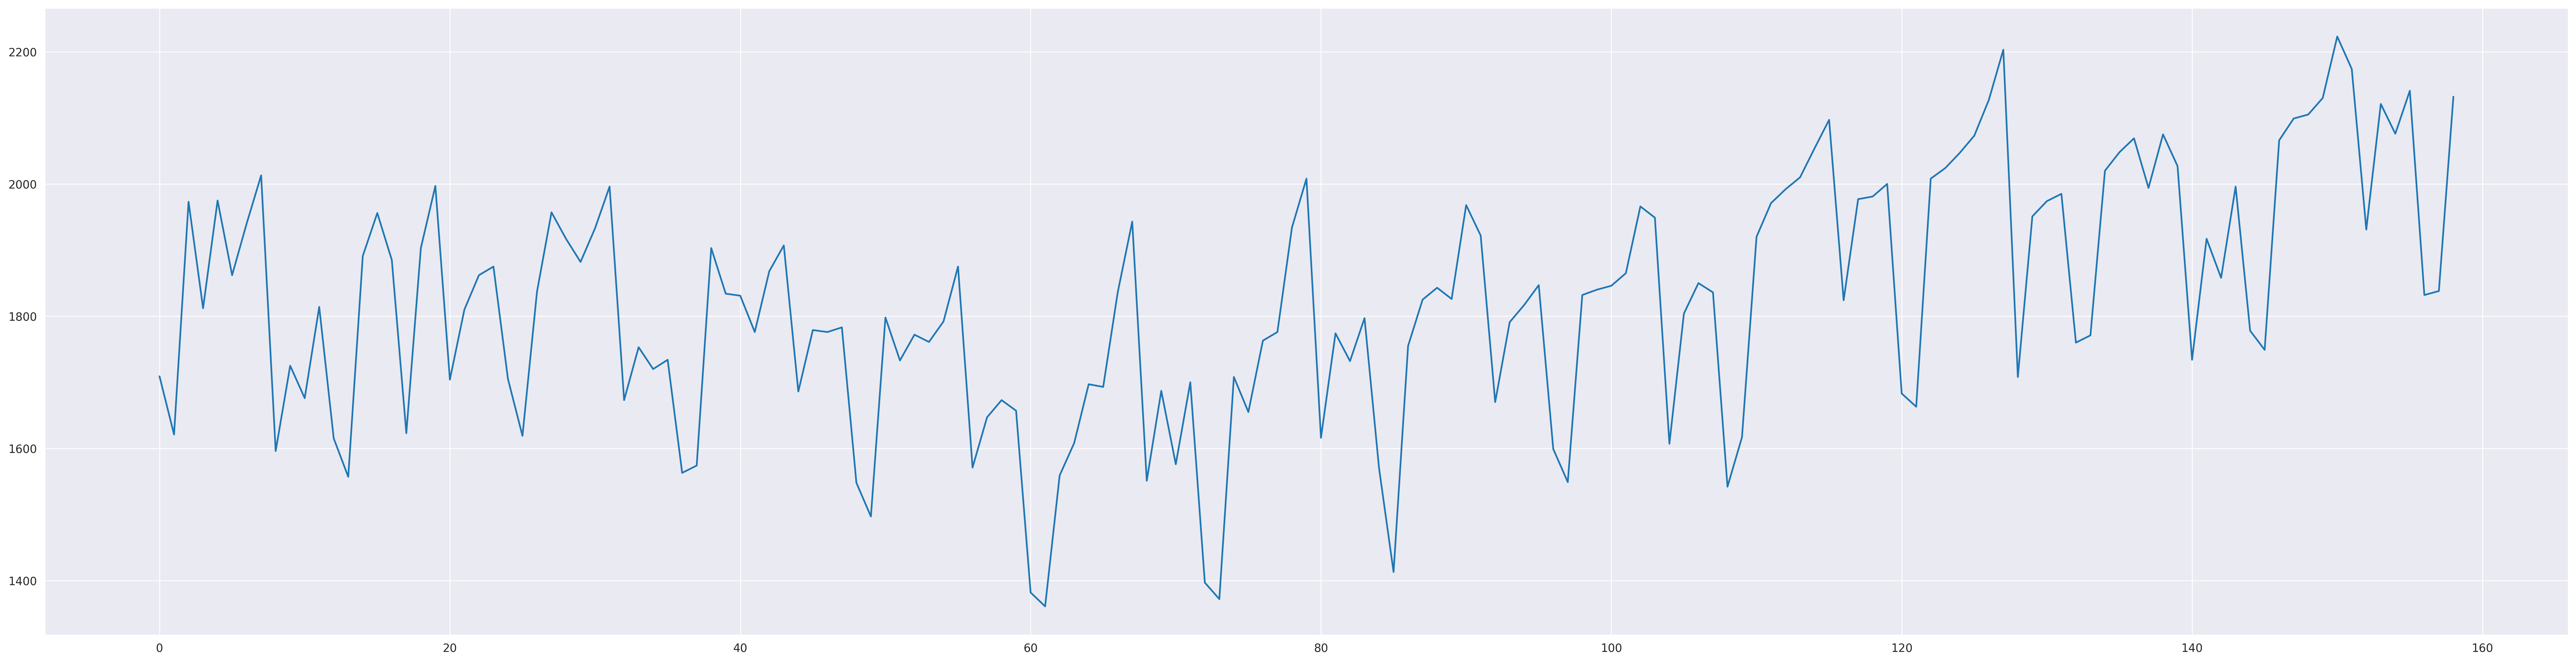

In [2]:
walmart = pd.read_csv("footfalls.csv")
walmart.Footfalls.plot()
# Trend = No Linear but quadratic kind of trend is there
# Seasonality = Additive, Non Stationary data - magnitude of cycle is changing.
# So you can select Additive Seasonality with Quadratic Trend Equation directly.

In [3]:
walmart.head()
# t - month (1st 2nd 3rd month and so on) - Independent feature
#Footfalls - in Jan 91 how many people visited Walmart and so on - target column
# check slide no. 33 in Forecasting-2 ppt.
# Log of Footfall is needed for Exponential model, t_square is required in Additive seasonality with Quadratic model.
# Jan to Dec are dummy variables for month column.

,Month,Footfalls,t,log_footfalls,t_square,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
0,Jan-91,1709,1,7.443664,1,1,0,0,0,0,0,0,0,0,0,0,0
1,Feb-91,1621,2,7.390799,4,0,1,0,0,0,0,0,0,0,0,0,0
2,Mar-91,1973,3,7.587311,9,0,0,1,0,0,0,0,0,0,0,0,0
3,Apr-91,1812,4,7.502186,16,0,0,0,1,0,0,0,0,0,0,0,0
4,May-91,1975,5,7.588324,25,0,0,0,0,1,0,0,0,0,0,0,0


In [4]:
walmart.shape # 159 months and 17 columns

(159, 17)

In [5]:
walmart.dtypes

,0
Month,object
Footfalls,int64
t,int64
log_footfalls,float64
t_square,int64
Jan,int64
Feb,int64
Mar,int64
Apr,int64
May,int64


In [6]:
# to make the model understand about month year column, we need to extract month and year from month column using to_datetime() method
walmart["Date"] = pd.to_datetime(walmart.Month, format="%b-%y") # %b - month, %y - year
walmart

,Month,Footfalls,t,log_footfalls,t_square,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Date
0,Jan-91,1709,1,7.443664,1,1,0,0,0,0,0,0,0,0,0,0,0,1991-01-01
1,Feb-91,1621,2,7.390799,4,0,1,0,0,0,0,0,0,0,0,0,0,1991-02-01
2,Mar-91,1973,3,7.587311,9,0,0,1,0,0,0,0,0,0,0,0,0,1991-03-01
3,Apr-91,1812,4,7.502186,16,0,0,0,1,0,0,0,0,0,0,0,0,1991-04-01
4,May-91,1975,5,7.588324,25,0,0,0,0,1,0,0,0,0,0,0,0,1991-05-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154,Nov-03,2076,155,7.638198,24025,0,0,0,0,0,0,0,0,0,0,1,0,2003-11-01
155,Dec-03,2141,156,7.669028,24336,0,0,0,0,0,0,0,0,0,0,0,1,2003-12-01
156,Jan-04,1832,157,7.513164,24649,1,0,0,0,0,0,0,0,0,0,0,0,2004-01-01
157,Feb-04,1838,158,7.516433,24964,0,1,0,0,0,0,0,0,0,0,0,0,2004-02-01


In [7]:
walmart.dtypes

,0
Month,object
Footfalls,int64
t,int64
log_footfalls,float64
t_square,int64
Jan,int64
Feb,int64
Mar,int64
Apr,int64
May,int64


In [8]:
walmart.shape

(159, 18)

In [9]:
# Extracting Day, Weekday name, month name, year from the date col. using date functions from pandas - only for plotting purpose
walmart["month"] = walmart.Date.dt.strftime("%b") # month extraction
walmart["year"] = walmart.Date.dt.strftime("%y") # year extraction

In [ ]:
walmart.head()

,Month,Footfalls,t,log_footfalls,t_square,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Date,month,year
0,Jan-91,1709,1,7.443664,1,1,0,0,0,0,0,0,0,0,0,0,0,1991-01-01,Jan,91
1,Feb-91,1621,2,7.390799,4,0,1,0,0,0,0,0,0,0,0,0,0,1991-02-01,Feb,91
2,Mar-91,1973,3,7.587311,9,0,0,1,0,0,0,0,0,0,0,0,0,1991-03-01,Mar,91
3,Apr-91,1812,4,7.502186,16,0,0,0,1,0,0,0,0,0,0,0,0,1991-04-01,Apr,91
4,May-91,1975,5,7.588324,25,0,0,0,0,1,0,0,0,0,0,0,0,1991-05-01,May,91


<Axes: xlabel='year', ylabel='Footfalls'>

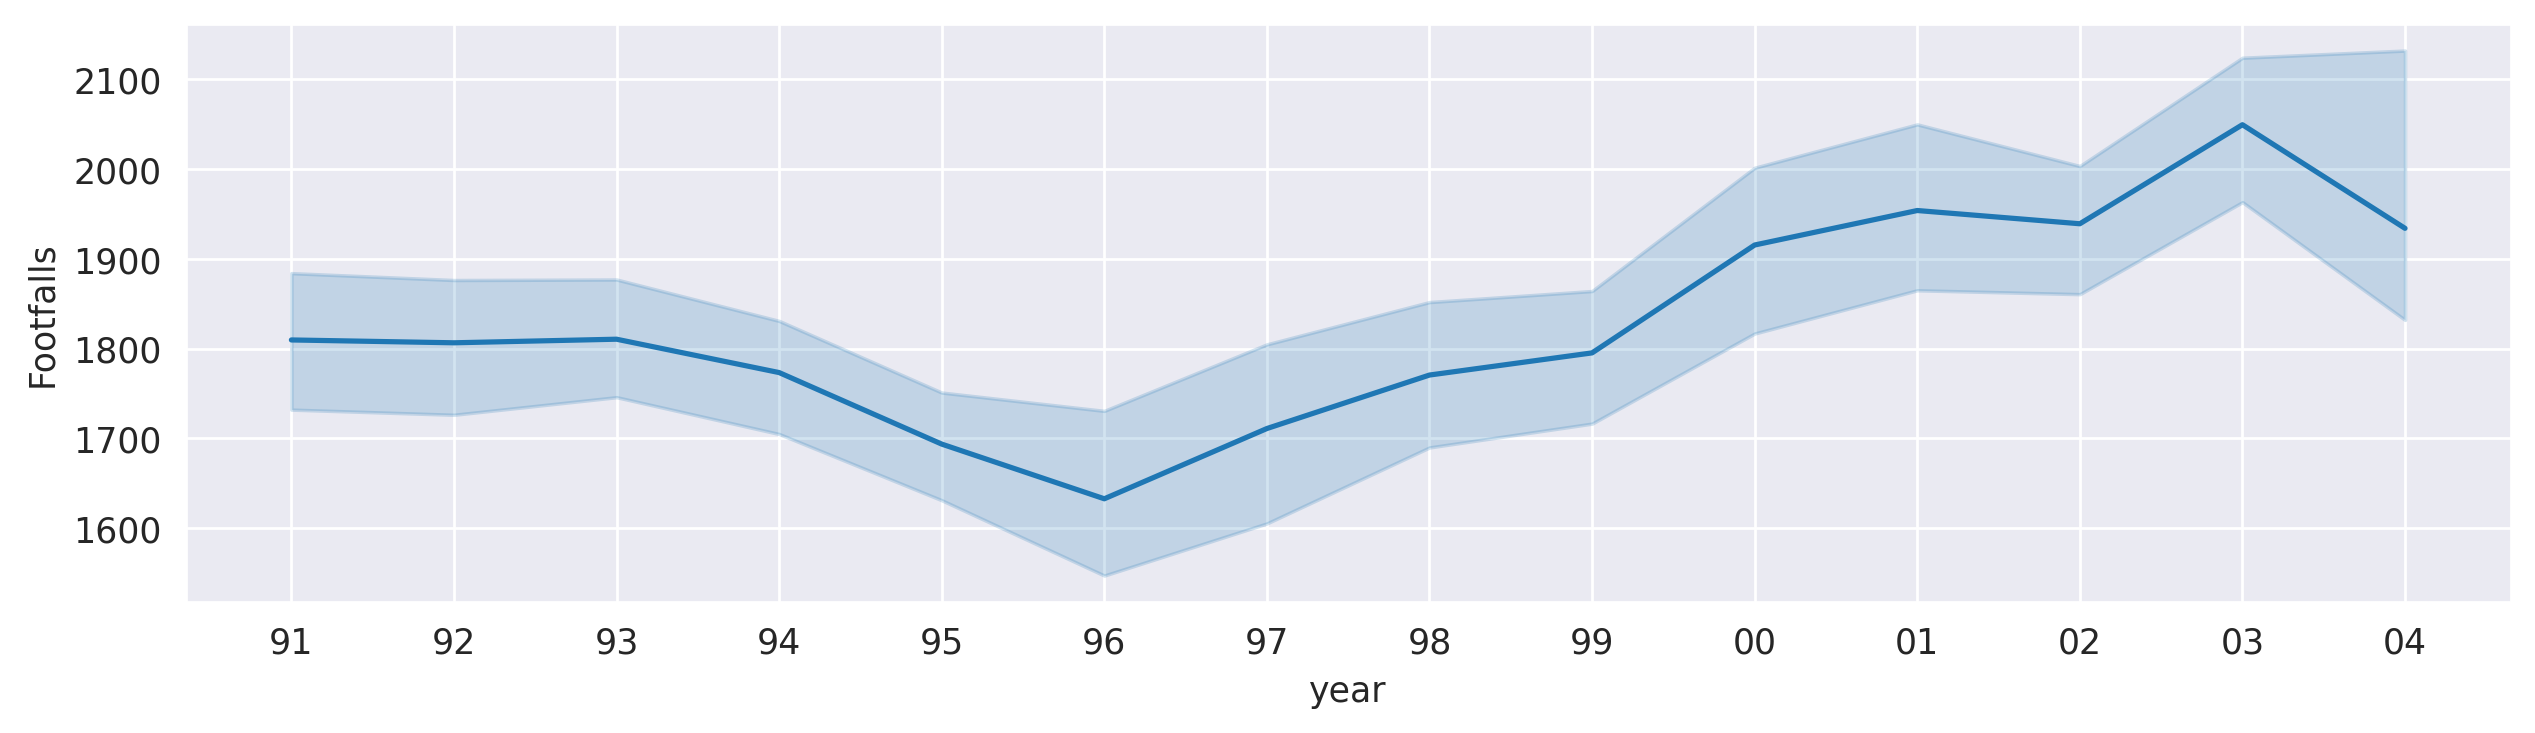

In [10]:
plt.figure(figsize=(12,3))
sns.lineplot(x="year",y="Footfalls",data=walmart)
# from 91 to 96 footfall was decreasing, then increased till 2003....

# Data Splitting

In [11]:
train = walmart.head(147)
test = walmart.tail(12)

In [ ]:
train

,Month,Footfalls,t,log_footfalls,t_square,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Date,month,year
0,Jan-91,1709,1,7.443664,1,1,0,0,0,0,0,0,0,0,0,0,0,1991-01-01,Jan,91
1,Feb-91,1621,2,7.390799,4,0,1,0,0,0,0,0,0,0,0,0,0,1991-02-01,Feb,91
2,Mar-91,1973,3,7.587311,9,0,0,1,0,0,0,0,0,0,0,0,0,1991-03-01,Mar,91
3,Apr-91,1812,4,7.502186,16,0,0,0,1,0,0,0,0,0,0,0,0,1991-04-01,Apr,91
4,May-91,1975,5,7.588324,25,0,0,0,0,1,0,0,0,0,0,0,0,1991-05-01,May,91
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,Nov-02,1858,143,7.527256,20449,0,0,0,0,0,0,0,0,0,0,1,0,2002-11-01,Nov,02
143,Dec-02,1996,144,7.598900,20736,0,0,0,0,0,0,0,0,0,0,0,1,2002-12-01,Dec,02
144,Jan-03,1778,145,7.483244,21025,1,0,0,0,0,0,0,0,0,0,0,0,2003-01-01,Jan,03
145,Feb-03,1749,146,7.466799,21316,0,1,0,0,0,0,0,0,0,0,0,0,2003-02-01,Feb,03


In [ ]:
test

,Month,Footfalls,t,log_footfalls,t_square,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Date,month,year
147,Apr-03,2099,148,7.649216,21904,0,0,0,1,0,0,0,0,0,0,0,0,2003-04-01,Apr,03
148,May-03,2105,149,7.652071,22201,0,0,0,0,1,0,0,0,0,0,0,0,2003-05-01,May,03
149,Jun-03,2130,150,7.663877,22500,0,0,0,0,0,1,0,0,0,0,0,0,2003-06-01,Jun,03
150,Jul-03,2223,151,7.706613,22801,0,0,0,0,0,0,1,0,0,0,0,0,2003-07-01,Jul,03
151,Aug-03,2174,152,7.684324,23104,0,0,0,0,0,0,0,1,0,0,0,0,2003-08-01,Aug,03
152,Sep-03,1931,153,7.565793,23409,0,0,0,0,0,0,0,0,1,0,0,0,2003-09-01,Sep,03
153,Oct-03,2121,154,7.659643,23716,0,0,0,0,0,0,0,0,0,1,0,0,2003-10-01,Oct,03
154,Nov-03,2076,155,7.638198,24025,0,0,0,0,0,0,0,0,0,0,1,0,2003-11-01,Nov,03
155,Dec-03,2141,156,7.669028,24336,0,0,0,0,0,0,0,0,0,0,0,1,2003-12-01,Dec,03
156,Jan-04,1832,157,7.513164,24649,1,0,0,0,0,0,0,0,0,0,0,0,2004-01-01,Jan,04


In [12]:
from sklearn.metrics import mean_squared_error

In [13]:
# Linear Model
import statsmodels.formula.api as smf

linear_model = smf.ols('Footfalls~t',data=train).fit() #Footfalls - target col, t - independent variable
pred_linear = pd.Series(linear_model.predict(pd.DataFrame(test['t']))) # get prediction for test data
rmse_linear = np.sqrt(mean_squared_error(test['Footfalls'],pred_linear)) # there is no direct built in function for rmst so take sqrt of MSE
rmse_linear # RMSE should be minimum. try all models. Whichever model will give you min, RMSE that will be our final model


np.float64(209.92559265462572)

In [14]:
# Exponential model

exp = smf.ols('log_footfalls~t',data=train).fit()
pred_exp = pd.Series(exp.predict(pd.DataFrame(test['t']))) # get prediction for test data
rmse_exp = np.sqrt(mean_squared_error(test['Footfalls'],pred_exp)) # there is no direct built in function for rmst so take sqrt of MSE
rmse_exp

np.float64(2062.9501154673767)

In [15]:
# Quadratic Model

quad = smf.ols('Footfalls~t+t_square',data=train).fit()
pred_quad = pd.Series(quad.predict(pd.DataFrame(test[['t','t_square']])))
rmse_quad = np.sqrt(mean_squared_error(test['Footfalls'],pred_quad))
rmse_quad

np.float64(137.15462741356146)

In [16]:
# Additive Seasonality Model - Pass from Jan to Nov

add_sea = smf.ols('Footfalls~Jan+Feb+Mar+Apr+May+Jun+Jul+Aug+Sep+Oct+Nov',data=train).fit()
pred_add_sea = pd.Series(add_sea.predict(pd.DataFrame(test[['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov']])))
rmse_add_sea = np.sqrt(mean_squared_error(test['Footfalls'],pred_add_sea))
rmse_add_sea

np.float64(264.6643900568774)

In [17]:
# Additive Seasonality Quadratic Model
add_sea_quad = smf.ols('Footfalls~t+t_square+Jan+Feb+Mar+Apr+May+Jun+Jul+Aug+Sep+Oct+Nov',data=train).fit()
pred_add_sea_quad = pd.Series(add_sea_quad.predict(pd.DataFrame(test[['t','t_square','Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov']])))
rmse_add_sea_quad = np.sqrt(mean_squared_error(test['Footfalls'],pred_add_sea_quad))
rmse_add_sea_quad

np.float64(50.607245841424444)

In [18]:
# Multiplicative Seasonality

mul_sea = smf.ols('log_footfalls~Jan+Feb+Mar+Apr+May+Jun+Jul+Aug+Sep+Oct+Nov',data=train).fit()
pred_mul_sea = pd.Series(mul_sea.predict(test[['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov']]))
rmse_mul_sea = np.sqrt(mean_squared_error(test['Footfalls'],pred_mul_sea))
rmse_mul_sea

np.float64(2062.996088663915)

In [19]:
# Compare the results

data = {"MODEL":pd.Series(['Linear','Exponential','Quadratic','Additive Seas','Additive Seas Quad','Multiplicative Seas']),
        "RMSE_Values":pd.Series([rmse_linear,rmse_exp,rmse_quad,rmse_add_sea,rmse_add_sea_quad,rmse_mul_sea])}
table_rmse=pd.DataFrame(data)
table_rmse.sort_values(["RMSE_Values"])
# RMSE value for additive seasonality with quadratic trend is giving less RMSE value so this model is good for this dataset.
# To predict the footfall for next 12 months additive seasonality with quadratic trend model should be used.

,MODEL,RMSE_Values
4,Additive Seas Quad,50.607246
2,Quadratic,137.154627
0,Linear,209.925593
3,Additive Seas,264.664390
1,Exponential,2062.950115
5,Multiplicative Seas,2062.996089
